In [1]:
from ecnet.datasets import load_cn

smiles, _ = load_cn()
smiles = smiles
print(smiles[:5])

['CC1=CC=C(O1)C(C2=CC=CO2)C3=CC=C(O3)C', 'CCCCC1=CC=CO1', 'C1CCOCC1', 'CC1=CC=C(C)O1', 'C1C=CCO1']


In [2]:
from preprocessing import SMILESEncoder
from structs import SMILESDataset
from sklearn.model_selection import train_test_split

smiles_train, smiles_test = train_test_split(smiles, test_size=0.2, random_state=24)

encoder = SMILESEncoder(smiles_train, max_tokens=42, n_merges=48)

vectors_train = encoder.encode(smiles_train)
vectors_test = encoder.encode(smiles_test)

dataset_train = SMILESDataset(vectors_train)
dataset_test = SMILESDataset(vectors_test)

print(len(dataset_train), len(dataset_test))


368 92


In [3]:
from chemvae import ChemVAE

print(dataset_train.shape)
print(dataset_train.shape_flat)

print(dataset_train.shape)
vae = ChemVAE(dataset_train.shape[2], 16, 128)
train_loss, valid_loss = vae.fit(
    dataset_train,
    verbose=1,
    epochs=250,
    lr=0.005,
    valid_size=0.2,
    random_state=25,
    shuffle=False
)

(368, 42, 59)
torch.Size([368, 42, 59])
(368, 42, 59)
Epoch: 0 | Training Loss: 19347.852532958983 | Valid Loss: 9223372036854775807
Epoch: 1 | Training Loss: 1626.118408203125 | Valid Loss: 1746.1716715494792
Epoch: 2 | Training Loss: 1514.8812896728516 | Valid Loss: 1258.337890625
Epoch: 3 | Training Loss: 1549.4607177734374 | Valid Loss: 1313.0650024414062


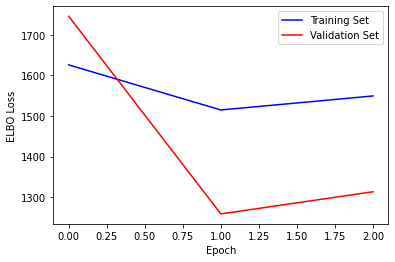

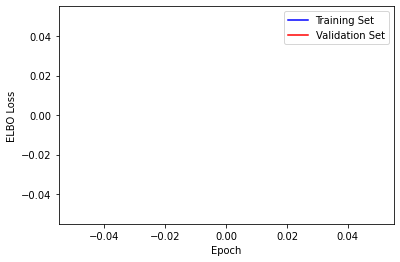

In [4]:
from matplotlib import pyplot as plt

plt.clf()
train_loss = train_loss[1:]
valid_loss = valid_loss[1:]
epochs = [i for i in range(len(train_loss))]
plt.plot(epochs, train_loss, color='blue', label='Training Set')
plt.plot(epochs, valid_loss, color='red', label='Validation Set')
plt.xlabel('Epoch')
plt.ylabel('ELBO Loss')
plt.legend(loc='upper right')
plt.show()

plt.clf()
train_loss = train_loss[5:]
valid_loss = valid_loss[5:]
epochs = [i for i in range(len(train_loss))]
plt.plot(epochs, train_loss, color='blue', label='Training Set')
plt.plot(epochs, valid_loss, color='red', label='Validation Set')
plt.xlabel('Epoch')
plt.ylabel('ELBO Loss')
plt.legend(loc='upper right')
plt.show()

In [5]:
test_recon, _, _ = vae(dataset_train.X)
test_vector_recon = test_recon.detach().numpy()
print(test_recon.shape, test_vector_recon.shape)

torch.Size([368, 42, 59]) (368, 42, 59)


In [6]:
print(max(test_vector_recon[1][0]))

0.90231544


In [7]:
from preprocessing import floats_to_onehot

test_recon_onehot = floats_to_onehot(test_vector_recon)
print(test_recon_onehot.shape)

(368, 42, 59)


In [8]:
test_recon_smiles = encoder.decode(test_recon_onehot)

In [9]:
print(test_recon_smiles[0])